# Graph 101: Fundamentals of Graph Representations
---

**Author:** Imad El Maftouhi

This notebook covers the fundamentals of graph representations as a stepping stone toward Graph Neural Networks (GNNs) and more advanced graph-based algorithms. Rather than starting from abstract theory, we build intuition through a concrete examples.

----

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data
from torch_geometric.utils import subgraph

from collections import defaultdict
from typing import Optional, Union, List, Tuple, Any

# What is a Graph ?

## 1.1 Informal Intuition

Before any formal definition, consider these everyday structures:

- A **map** of cities connected by roads
- A **social network** where people follow each other
- A **molecule** where atoms are bonded together
- A **web page** linking to other web pages

All of these share a common pattern: **entities** and **relationships between them**. A graph is simply the mathematical abstraction of that pattern.

## 1.2 Formal Definition

A graph **G** is defined as a pair:

$$G = (V, E)$$

Where:
- **V** is a finite set of **vertices** (also called **nodes**) — the entities
- **E** is a set of **edges** — the relationships between entities

Each edge $e \in E$ connects a pair of nodes $(u, v)$ where $u, v \in V$.

**Example:**

Consider 4 cities connected by direct train routes:

```
V = {Paris, Lyon, Marseille, Bordeaux}
E = {(Paris, Lyon), (Lyon, Marseille), (Paris, Bordeaux)}
```

This gives a graph with **4 nodes** and **3 edges**.

## 1.3 Directed vs Undirected Graphs

The nature of the relationship between two nodes determines whether a graph is **directed** or **undirected**.

### Undirected Graph
An edge $(u, v)$ has **no direction** — the relationship is symmetric. If $u$ is connected to $v$, then $v$ is connected to $u$.

$$E \subseteq \big\{\{u, v\} \mid u, v \in V,\ u \neq v\big\}$$

**Examples:** friendship on Facebook, road between two cities, pixel neighborhood in an image.

```
A ── B
|   |
C ── D
```

### Directed Graph (Digraph)
An edge $(u, v)$ has a **direction** — it goes *from* $u$ *to* $v$. The reverse edge $(v, u)$ is a different edge and may or may not exist.

$$E \subseteq \big\{(u, v) \mid u, v \in V,\ u \neq v\big\}$$

**Examples:** following on Twitter, hyperlinks between web pages, citation networks.

```
A ──► B
▲     |
|     ▼
C ◄── D
```

> **Key distinction:** In an undirected graph, edges are *sets* $\{u, v\}$ — order doesn't matter. In a directed graph, edges are *ordered pairs* $(u, v)$ — order matters.

## 1.4 Weighted vs Unweighted Graphs

So far, edges only encode *whether* a connection exists. Often we also want to encode *how strong* or *how costly* a connection is — this is done with **weights**.

### Unweighted Graph
Every edge is equally significant. The edge either exists or it doesn't.

### Weighted Graph
Each edge $e = (u, v)$ carries a scalar weight $w(u, v) \in \mathbb{R}$:

$$G = (V, E, w) \quad \text{where} \quad w: E \to \mathbb{R}$$

**Examples:**
| Graph | Weight meaning |
|---|---|
| Road network | Distance in km |
| Molecule | Bond strength |
| Pixel graph | Color dissimilarity between adjacent pixels |
| Social network | Interaction frequency |

Weights can represent **cost**, **capacity**, **similarity**, **distance**, or any numeric relationship between nodes.

## 1.5 Node and Edge Features

In machine learning we go beyond topology and attach **feature vectors** to nodes and edges:

- **Node features** $\mathbf{x}_v \in \mathbb{R}^d$ — properties of the entity itself
- **Edge features** $\mathbf{e}_{uv} \in \mathbb{R}^k$ — properties of the relationship

| Domain | Node features | Edge features |
|---|---|---|
| Social network | Age, location, interests | Friendship duration |
| Molecule | Atom type, charge | Bond type, bond length |
| Image | RGB pixel values | Color distance between neighbors |
| Road network | City population | Road length, speed limit |


> In PyTorch Geometric, node features are stored as `x` of shape `[num_nodes, num_features]`, and edge features as `edge_attr` of shape `[num_edges, num_edge_features]`.

## 1.6 Simple Graphs vs Multigraphs

A **simple graph** allows at most one edge between any pair of nodes and no self-loops (an edge from a node to itself).

A **multigraph** relaxes these constraints:

| Variant | What it allows |
|---|---|
| Multigraph | Multiple edges between the same pair of nodes |
| Graph with self-loops | A node can have an edge pointing to itself |

**When do these arise?**
- A person can send multiple messages to another → multigraph
- A neuron with a recurrent connection → self-loop
- A knowledge graph with multiple relation types between the same entities → multigraph

Most GNN frameworks assume simple graphs by default, but PyG supports both multigraphs and self-loops.

## 1.7 Adjacency — Who is Connected to Whom?

The **adjacency** of a node $v$ is the set of nodes it is directly connected to, also called its **neighbors**:

$$\mathcal{N}(v) = \{u \in V \mid (v, u) \in E\}$$

The **degree** of a node is the number of its neighbors:

$$\deg(v) = |\mathcal{N}(v)|$$

In a directed graph we distinguish:
- **In-degree**: number of edges *arriving at* $v$
- **Out-degree**: number of edges *leaving* $v$

**Example:** In the image graph we built, every interior pixel has degree 8 (8 neighbors), edge pixels have degree 5, and corner pixels have degree 3.

## 1.8 Summary

| Property | Options |
|---|---|
| Edge direction | Directed / Undirected |
| Edge weights | Weighted / Unweighted |
| Node features | Present / Absent |
| Edge features | Present / Absent |
| Self-loops | Allowed / Forbidden |
| Multi-edges | Allowed / Forbidden |

A typical graph used in a GNN is **directed or undirected**, **weighted**, with **node and edge features**, and is assumed to be a **simple graph** unless stated otherwise.

## 1.9 Real-World Examples

| Domain | Nodes | Edges | Node features | Edge features |
|---|---|---|---|---|
| Social network | Users | Follows / Friends | Profile info | Interaction frequency |
| Citation network | Papers | Paper A cites B | Abstract embeddings | — |
| Molecule | Atoms | Chemical bonds | Atom type, charge | Bond type |
| Knowledge graph | Entities | Relations (*is-a*, *part-of*) | Entity embeddings | Relation type |
| Image | Pixels | Spatial adjacency (8-connectivity) | RGB values | Color dissimilarity |
| Road network | Intersections | Road segments | Coordinates | Length, speed limit |
| Brain connectivity | Brain regions | Neural connections | Activation levels | Connection strength |

---

> **Coming up next →** Section 2 covers how graphs are *represented in memory* — adjacency matrices, adjacency lists, and the COO edge list format used by PyTorch Geometric.

---


# 2. Graph Representations 

(In-code)

- Adjacency matrix
- Adjacency list
- Edge list / COO format (what PyG uses)
- Trade-offs: memory, lookup speed, sparsity

In [11]:
# let's first construct a simple graph and then we will see the code for different representations
nodes = ["A", "B", "C", "D", "E", "F", "G", "H"]
edges = [(0, 1),(0, 2),(1, 3),(2, 3),(3, 4),(4, 5),(5, 6),(6, 7),(7, 0),(1, 4),(2, 5),(3, 6)]

"""
An adjacency matrix is a 2D square array where the rows and columns represent the nodes of the graph. The value at the intersection of a row and column indicates whether there is an edge between the corresponding nodes. For example, if there is an edge from node A to node B, then the value at the intersection of row A and column B would be 1 (or True), while if there is no edge, it would be 0 (or False). We can also use weights instead of binary values to represent the strength or cost of the connection between nodes.
If the graph is undirected, the adjacency matrix will be symmetric, meaning that the value at the intersection of row A and column B will be the same as the value at the intersection of row B and column A. If the graph is directed, the adjacency matrix may not be symmetric, as there may be an edge from node A to node B but not from node B to node A. 
"""    

adjacency_matrix = np.zeros((len(nodes), len(nodes)), dtype=int)
for node in nodes:
    # print(f"Processing node '{node}'")
    for edge in edges:
        # print(f"Checking edge {edge} for node '{node}'")
        if node in edge:
            # print(f"Node '{node}' is part of edge {edge}")
            other_node = edge[1] if edge[0] == node else edge[0]
            # print(f"Other node connected to '{node}' is '{other_node}'")
            adjacency_matrix[nodes.index(node), nodes.index(other_node)] = 1
print("Adjacency Matrix:", adjacency_matrix) 


Adjacency Matrix: [[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [14]:
# adjacency list is a collection of lists or dictionaries where each key represents a node and the corresponding value is a list of neighboring nodes. For example, if node A is connected to nodes B and C, then the adjacency list would have an entry like A: [B, C]. This representation is more space-efficient for sparse graphs, as it only stores the existing edges rather than all possible connections.
adjacency_list = defaultdict(list)
for edge in edges:
    adjacency_list[edge[0]].append(edge[1])
    adjacency_list[edge[1]].append(edge[0])  # For undirected graph

print("Adjacency List:", dict(adjacency_list))

Adjacency List: {0: [1, 2, 7], 1: [0, 3, 4], 2: [0, 3, 5], 3: [1, 2, 4, 6], 4: [3, 5, 1], 5: [4, 6, 2], 6: [5, 7, 3], 7: [6, 0]}


In [17]:
"""
- Edge list is a simple representation of a graph where each edge is represented as a pair of nodes. For example, if there is an edge between node A and node B, it can be represented as (A, B). This representation is straightforward and easy to understand, but it may not be the most efficient for certain graph algorithms, especially when dealing with large graphs. It can also be less efficient in terms of space complexity compared to adjacency lists or matrices, as it may require more storage for large graphs with many edges.

- COO format is a sparse matrix format that represents a graph using three arrays: row, column, and data. The row array contains the row indices of the non-zero entries, the column array contains the column indices of the non-zero entries, and the data array contains the values of the non-zero entries. In the context of a graph, the row and column arrays represent the source and target nodes of the edges, respectively, while the data array can represent edge weights or simply indicate the presence of an edge (e.g., with a value of 1). This format is particularly efficient for storing and processing sparse graphs, as it only stores information about existing edges rather than all possible connections.

"""

edge_list = np.array(edges).T
print(f"Edge list in COO format : {edge_list}")

Edge list in COO format : [[0 0 1 2 3 4 5 6 7 1 2 3]
 [1 2 3 3 4 5 6 7 0 4 5 6]]


In [18]:
import time

# Comparison of Graph Representations: Space and Time Complexity

# Assuming a graph with n nodes and m edges

# 1. Adjacency Matrix
# - Space: O(n^2) - stores all possible pairs, even if no edge exists
# - Check edge existence: O(1) - direct array access
# - Iterate neighbors: O(n) - scan entire row
# - Suitable for dense graphs

# 2. Adjacency List
# - Space: O(n + m) - only stores existing edges
# - Check edge existence: O(degree(u)) - scan list of neighbors
# - Iterate neighbors: O(degree(u)) - direct list traversal
# - Suitable for sparse graphs

# 3. Edge List / COO Format
# - Space: O(m) - only stores edges
# - Check edge existence: O(m) - scan entire list
# - Iterate neighbors: O(m) - requires building adjacency from edges first
# - Suitable for very sparse graphs or when edges are the focus

# Example with the current graph (n=8, m=12)
n = len(nodes)
m = len(edges)

print(f"Graph: {n} nodes, {m} edges")
print(f"Adjacency Matrix space: {n*n} entries (dense)")
print(f"Adjacency List space: {sum(len(adjacency_list[i]) for i in adjacency_list)} entries (sparse)")
print(f"Edge List space: {m} entries")

# Time examples (simplified, not actual timing)

# Check edge (0,1) exists
start = time.time()
exists_matrix = adjacency_matrix[0,1] == 1
print(f"Matrix check: {time.time()-start:.6f}s, result: {exists_matrix}")

start = time.time()
exists_list = 1 in adjacency_list[0]
print(f"List check: {time.time()-start:.6f}s, result: {exists_list}")

start = time.time()
exists_edge = (0,1) in edges
print(f"Edge list check: {time.time()-start:.6f}s, result: {exists_edge}")

# Iterate neighbors of node 0
print("Neighbors of 0 (matrix):", [i for i in range(n) if adjacency_matrix[0,i] == 1])
print("Neighbors of 0 (list):", adjacency_list[0])
print("Neighbors of 0 (edge list):", [e[1] for e in edges if e[0]==0] + [e[0] for e in edges if e[1]==0])

Graph: 8 nodes, 12 edges
Adjacency Matrix space: 64 entries (dense)
Adjacency List space: 24 entries (sparse)
Edge List space: 12 entries
Matrix check: 0.002135s, result: False
List check: 0.000000s, result: True
Edge list check: 0.000000s, result: True
Neighbors of 0 (matrix): []
Neighbors of 0 (list): [1, 2, 7]
Neighbors of 0 (edge list): [1, 2, 7]


# Node and Edge Features

- What node features represent
- What edge features represent
- Feature normalization

# Graph properties & Metrics

- Degree, in-degree, out-degree
- Density
- Connectivity (connected components)
- Paths, shortest paths
- Diameter
- Clustering coefficient

# Types of Graphs (with examples)

- Trees
- DAGs (Directed Acyclic Graphs)
- Bipartite graphs
- Heterogeneous graphs
- Dynamic graphs

# Classic Graph Algorithms

- BFS and DFS (traversal)
- Dijkstra (shortest path)
- PageRank (Node importance)
- Connected components

# Graph as a Matrix : The Linear Algebra View
- Adjacency Matrix A
- Degree matrix D
- Laplacien L = D-A
- why the Laplacien matters (leads directly into spectral GNNs)

# Practical: Building Graphs from real data

- Building a graph from an image
- From a CSV/tabular dataset
- from a molecule (RDKit)
- From a social network

## Building a Graph from an Image

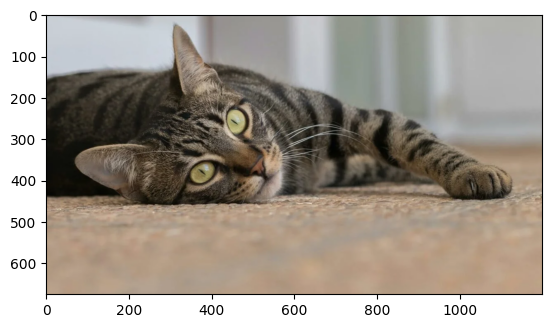

In [2]:
# task 1 : Represent an image as a graph
image = cv2.imread('../misc/cat.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [3]:
print("Type of image variable:", type(image))
print("Shape of image variable:", image.shape)
print("Data type of image variable:", image.dtype)
print("image : \n", image)

Type of image variable: <class 'numpy.ndarray'>
Shape of image variable: (675, 1200, 3)
Data type of image variable: uint8
image : 
 [[[199 205 210]
  [199 205 210]
  [199 205 210]
  ...
  [179 180 175]
  [179 180 175]
  [179 180 175]]

 [[199 205 210]
  [199 205 210]
  [199 205 210]
  ...
  [179 180 175]
  [179 180 175]
  [179 180 175]]

 [[200 206 211]
  [200 206 211]
  [200 206 211]
  ...
  [179 180 175]
  [179 180 175]
  [179 180 175]]

 ...

 [[188 165 141]
  [188 165 141]
  [188 165 141]
  ...
  [188 159 137]
  [188 159 137]
  [188 159 137]]

 [[188 165 141]
  [188 165 141]
  [188 165 141]
  ...
  [188 159 137]
  [188 159 137]
  [188 159 137]]

 [[188 165 141]
  [188 165 141]
  [188 165 141]
  ...
  [188 159 137]
  [188 159 137]
  [188 159 137]]]


Now how de we actually move from a 2D array to a graph structure ? We could consider each pixel as a node and then connect the nodes based on their spatial proximity. For example, we could connect each pixel to its 8 neighboring pixels (the ones that are directly adjacent to it). This way, we can create a graph where each node represents a pixel and the edges represent the connections between neighboring pixels.
We can also assign features to each node (pixel) based on its color values (RGB) and possibly other attributes like intensity or texture. This way, we can use the graph structure to perform various tasks such as image segmentation, object recognition, or even image generation using Graph Neural Networks (GNNs).
To summarize, representing an image as a graph involves treating each pixel as a node and connecting them based on their spatial relationships, while also assigning features to the nodes to capture the information contained in the image.

In [18]:
# reshape the (H,W,3) array into a (H*W,3) array
if image is None:
    raise ValueError("Image not found. Please check the file path.")
H, W, C = image.shape
image_reshaped = image.reshape(-1, C) # node feature matrix
image_reshaped = image_reshaped / 255.0 #normalize to (0,1)
print("Reshaped image shape:", image_reshaped.shape)
# The core operation is img.reshape(-1, 3). The -1 tells NumPy to infer that dimension automatically -- it computes H×W for you. The result is your node feature matrix X where row n corresponds to the pixel at (i, j) via n = i*W + j. The three columns are the raw R, G, B values.

Reshaped image shape: (810000, 3)


In [36]:
# building the edge index 
#for every pixel, find its valid neighbors, record the directed pair (src,dst) and stack all pairs into a (2, num_edges) tensor
# Corner pixels end up with 3 neighbors, edge pixels with 5, and interior pixels with the full 8
# the edges are directed, meaning A->B and B->A are considered different edges. This is important for many GNN architectures that treat incoming and outgoing edges differently.
# the final edge_index shape is (2,E) where E grows with image size roughly as 8*H*W for large images (since most pixels have 8 neighbors). For a 100x100 image, you might have around 80,000 edges. We typically wan to keep edge_index as torch.long tensor on the same device as your node features for efficient processing in GNNs.

offsets = [(-1, -1), (-1, 0), (-1, 1),
           (0, -1),           (0, 1),
           (1, -1),  (1, 0),  (1, 1)]

sources = []
destinations = []
for i in range(H):
    for j in range(W):
        node_index = i * W + j
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < H and 0 <= nj < W: #boundary check
                neighbor_node_index = ni * W + nj
                sources.append(node_index)
                destinations.append(neighbor_node_index)

# edge_index = np.stack([np.array(sources, dtype=np.int64),
#                        np.array(destinations, dtype=np.int64)], axis=0)

edge_index = torch.tensor([sources, destinations], dtype=torch.long)
X = torch.tensor(image_reshaped, dtype=torch.float32)

In [37]:
print("Edge index shape:", edge_index.shape)
print(edge_index)

Edge index shape: torch.Size([2, 6468754])
tensor([[     0,      0,      0,  ..., 809999, 809999, 809999],
        [     1,   1200,   1201,  ..., 808798, 808799, 809998]])


In [44]:
u, v = edge_index
diff = X[u] - X[v]
dist = diff.norm(dim=1)
edge_attr = dist.unsqueeze(1) # shape (E,1)
print(" edge attributes shape:", edge_attr.shape)
# The raw L2 distance in RGB sapce ranges from 0 to sqrt(3) * 255 ~ 441.67. Most GNN layers expect inputs in a bounded range. Normalizing to (0,1) can help stabilize training and make the edge attributes more comparable across different images. `dist = dist / (255.0 * 3**0.5)`
# 

 edge attributes shape: torch.Size([6468754, 1])


In [45]:
# using torch_geometric's Data class to represent the graph
data = Data(
    x = X, # node feature matrix (H*W, 3)
    edge_index = edge_index, # Graph topology (2, E)
    edge_attr = edge_attr, # Optional edge features, one row per edge
    y = None # Optional label; cab be a saclar (graph classification) or a vector per node
)

In [58]:
# validate edge_attr values
print("Min edge attribute value:", edge_attr.min())
print("Max edge attribute value:", edge_attr.max())
print("mean edge attribute value:", edge_attr.mean())
print("edge_attr sample values:", edge_attr[:10])

Min edge attribute value: tensor(0.)
Max edge attribute value: tensor(1.0461)
mean edge attribute value: tensor(0.0222)
edge_attr sample values: tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [59]:
print(data.validate(raise_on_error=True))
print(data.is_undirected()) # should return False since we created directed edges
print(data.num_nodes)
print(data.num_edges)

True
True
810000
6468754


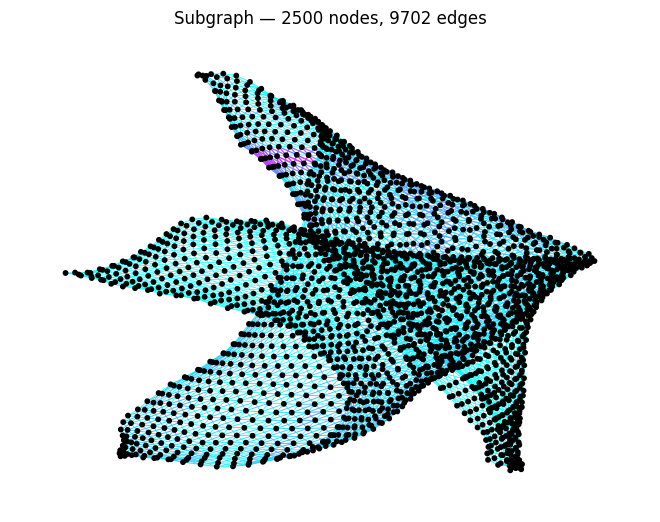

In [64]:
# --- Extract a small spatial patch ---
PATCH_ROW, PATCH_COL = 100, 100
PATCH_SIZE = 50  # 50x50 = 2500 nodes

patch_nodes = [
    (PATCH_ROW + i) * W + (PATCH_COL + j)
    for i in range(PATCH_SIZE)
    for j in range(PATCH_SIZE)
]

# --- Build a subgraph Data object ---
patch_nodes_tensor = torch.tensor(patch_nodes, dtype=torch.long)

sub_edge_index, sub_edge_attr = subgraph(   # <-- unpack attr directly, no mask
    patch_nodes_tensor,
    data.edge_index,
    edge_attr=data.edge_attr,
    relabel_nodes=True,
)
sub_x = data.x[patch_nodes_tensor]
sub_data = Data(x=sub_x, edge_index=sub_edge_index, edge_attr=sub_edge_attr)

G = to_networkx(sub_data, to_undirected=True, edge_attrs=['edge_attr'])

# Read weights in the exact order G.edges() returns them — avoids count mismatch
edge_weights = np.array([G[u][v]['edge_attr'][0] for u, v in G.edges()])
edge_widths = 0.5 + edge_weights * 3.0
edge_colors = plt.cm.cool(edge_weights / edge_weights.max())

node_colors = sub_x.numpy() / 255.0

nx.draw(G,
        node_color=node_colors,
        with_labels=False,
        node_size=10,
        edge_color=edge_colors,
        width=edge_widths)
plt.title(f"Subgraph — {sub_data.num_nodes} nodes, {sub_data.num_edges // 2} edges")
plt.show()


# Custom Graph Implementation/Class

In [66]:
# implementation of Graph class

class Graph:
    """
    A clean, flexible, and efficient Graph data structure for PyTorch Geometric-style graphs.
    Supports both CPU and GPU tensors.
    """
    
    def __init__(self,x: torch.Tensor,edge_index: torch.Tensor,edge_attr: Optional[torch.Tensor] = None,y: Optional[torch.Tensor] = None,num_nodes: Optional[int] = None,**kwargs: Any
):
        """
        Args:
            x: Node feature matrix of shape [num_nodes, num_node_features]
            edge_index: Edge index tensor of shape [2, num_edges] (COO format)
            edge_attr: Edge feature matrix of shape [num_edges, num_edge_features] (optional)
            y: Graph-level or node-level target labels (optional)
            num_nodes: Number of nodes (inferred from x or edge_index if not provided)
            **kwargs: Additional graph attributes (e.g. pos, batch, etc.)
        """
        # Validation
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        if not isinstance(edge_index, torch.Tensor):
            edge_index = torch.tensor(edge_index, dtype=torch.long)
        
        if edge_index.dim() != 2 or edge_index.size(0) != 2:
            raise ValueError("edge_index must be a tensor of shape [2, num_edges]")
        
        # Store core attributes
        self.x = x
        self.edge_index = edge_index
        self.edge_attr = edge_attr
        self.y = y
        self.num_nodes = num_nodes or x.size(0)
        
        # Store any additional attributes
        for key, value in kwargs.items():
            setattr(self, key, value)
    
    @property
    def num_edges(self) -> int:
        """Number of edges in the graph."""
        return self.edge_index.size(1)
    
    @property
    def num_node_features(self) -> int:
        """Number of features per node."""
        return self.x.size(1) if self.x.dim() > 1 else 1
    
    @property
    def num_edge_features(self) -> int:
        """Number of features per edge."""
        if self.edge_attr is None:
            return 0
        return self.edge_attr.size(1) if self.edge_attr.dim() > 1 else 1
    
    def is_directed(self) -> bool:
        """Check if the graph is directed."""
        row, col = self.edge_index
        # Check if for every edge (u, v), the reverse edge (v, u) also exists
        reverse_edges = torch.stack([col, row], dim=0)
        # Create a set of edge tuples for comparison
        edge_set = set(map(tuple, self.edge_index.t().tolist()))
        reverse_set = set(map(tuple, reverse_edges.t().tolist()))
        return not reverse_set.issubset(edge_set)
    
    def to(self, device: Union[str, torch.device]) -> 'Graph':
        """Move all tensors to the specified device (cpu/cuda)."""
        for key in self.__dict__:
            value = getattr(self, key)
            if isinstance(value, torch.Tensor):
                setattr(self, key, value.to(device))
        return self
    
    def cpu(self) -> 'Graph':
        return self.to('cpu')
    
    def cuda(self) -> 'Graph':
        return self.to('cuda')
    
    def __repr__(self) -> str:
        return (f"Graph(num_nodes={self.num_nodes}, "
                f"num_edges={self.num_edges}, "
                f"num_node_features={self.num_node_features}, "
                f"num_edge_features={self.num_edge_features})")    

In [ ]:
# visualise the custom graph class using pyvis
from pyvis.network import Network

# --- Config ---
PATCH_ROW, PATCH_COL = 100, 100   # top-left corner of the patch
PATCH_SIZE = 20                    # 20x20 = 400 nodes, manageable for pyvis

# --- Extract patch nodes (spatially connected) ---
patch_nodes = [
    (PATCH_ROW + i) * W + (PATCH_COL + j)
    for i in range(PATCH_SIZE)
    for j in range(PATCH_SIZE)
]
subgraph_nx = graph_nx.subgraph(patch_nodes)


# Make a mutable copy and strip non-serializable attributes
subgraph_nx = graph_nx.subgraph(patch_nodes).copy()
for node_id in subgraph_nx.nodes():
    subgraph_nx.nodes[node_id].pop('feature', None)

# Assign RGB color to each node
for node_id in subgraph_nx.nodes():
    r, g, b = image_reshaped[node_id]
    subgraph_nx.nodes[node_id]['color'] = f'rgb({r},{g},{b})'
    subgraph_nx.nodes[node_id]['size'] = 5
    subgraph_nx.nodes[node_id]['label'] = ''


# --- Build pyvis network ---
net = Network(height='750px', width='100%', directed=False, notebook=True)
net.from_nx(subgraph_nx)
net.show_buttons(filter_=['physics'])
net.show('graph_visualization.html')

print(f"Subgraph: {subgraph_nx.number_of_nodes()} nodes, {subgraph_nx.number_of_edges()} edges")

graph_visualization.html
Subgraph: 400 nodes, 1482 edges
